<a href="https://colab.research.google.com/github/harishmk31/24ADI003_24BAD031/blob/main/scenario5_exp6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

HARISH MK
24BAD031
    Amount   Time  Feature1  Feature2  Fraud
0  3233.38  34595  2.157308 -0.818199      0
1  2783.63  73166  1.561511  0.955305      0
2   923.74  84417 -0.027305 -1.418366      0
3  2214.14  11139 -0.643518 -0.466037      0
4   444.75  37847  0.021272 -0.529053      0

Missing values:
 Amount      0
Time        0
Feature1    0
Feature2    0
Fraud       0
dtype: int64

Normal : 110
Fraud  : 10
Fraud %: 8.33%

MODEL A
0.9 0.0 0.0 0.13223443223443224

MODEL B
0.7 0.6666666666666666 0.3076923076923077 0.2

MODEL C
0.5100000000000001 0.7333333333333333 0.6666666666666666 0.3333333333333333 0.2222222222222222

SUMMARY
0.9 0.7 0.7333333333333333
0.0 0.6666666666666666 0.6666666666666666
0.0 0.3076923076923077 0.3333333333333333


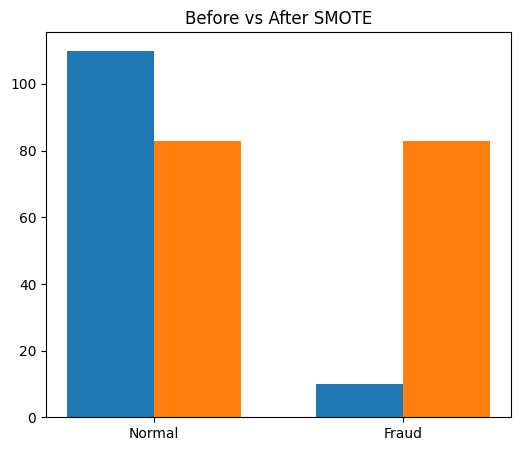

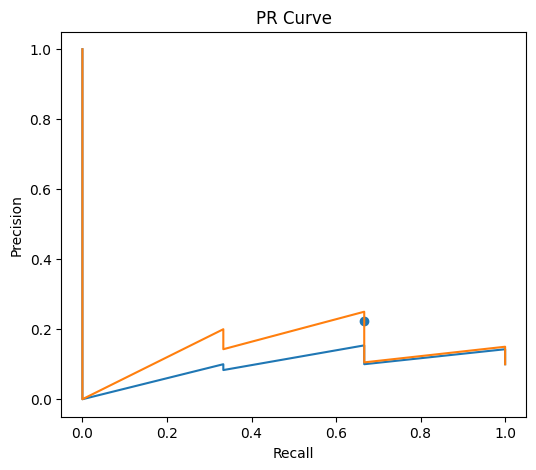

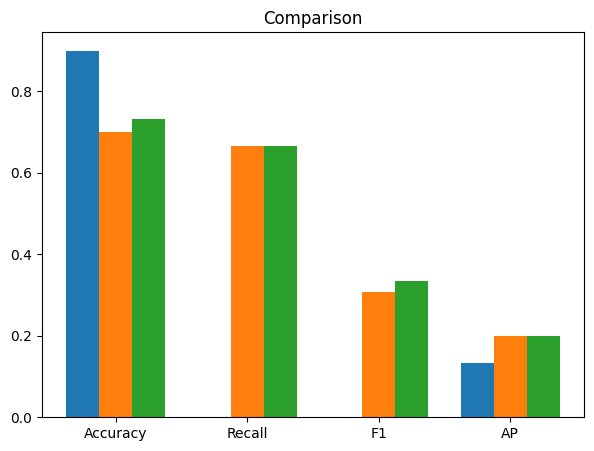

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import f1_score, recall_score, precision_score
from imblearn.over_sampling import SMOTE

print("HARISH MK")
print("24BAD031")

df = pd.read_csv("fraud_smote.csv")

print(df.head())
print("\nMissing values:\n", df.isnull().sum())

class_counts = df['Fraud'].value_counts()
fraud_count = class_counts.get(1, 0)
normal_count = class_counts.get(0, 0)
fraud_pct = fraud_count / len(df) * 100

print(f"\nNormal : {normal_count}")
print(f"Fraud  : {fraud_count}")
print(f"Fraud %: {fraud_pct:.2f}%")

feature_names = ['Amount', 'Time', 'Feature1', 'Feature2']
X = df[feature_names]
y = df['Fraud']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=7, stratify=y
)

lr_plain = LogisticRegression(max_iter=1000, random_state=42)
lr_plain.fit(X_train, y_train)

y_pred_plain = lr_plain.predict(X_test)
y_prob_plain = lr_plain.predict_proba(X_test)[:, 1]

acc_plain = accuracy_score(y_test, y_pred_plain)
rec_plain = recall_score(y_test, y_pred_plain, zero_division=0)
f1_plain = f1_score(y_test, y_pred_plain, zero_division=0)
ap_plain = average_precision_score(y_test, y_prob_plain)

print("\nMODEL A")
print(acc_plain, rec_plain, f1_plain, ap_plain)

fraud_train_count = int(y_train.sum())
k = max(1, min(fraud_train_count - 1, 5))

smote = SMOTE(k_neighbors=k, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

sm_counts = pd.Series(y_train_sm).value_counts()

lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_sm, y_train_sm)

y_pred_smote = lr_smote.predict(X_test)
y_prob_smote = lr_smote.predict_proba(X_test)[:, 1]

acc_smote = accuracy_score(y_test, y_pred_smote)
rec_smote = recall_score(y_test, y_pred_smote, zero_division=0)
f1_smote = f1_score(y_test, y_pred_smote, zero_division=0)
ap_smote = average_precision_score(y_test, y_prob_smote)

print("\nMODEL B")
print(acc_smote, rec_smote, f1_smote, ap_smote)

best_thresh = 0.5
best_f1_val = 0.0

for thresh in np.arange(0.05, 0.95, 0.01):
    y_pred_t = (y_prob_smote >= thresh).astype(int)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    if f > best_f1_val:
        best_f1_val = f
        best_thresh = thresh

y_pred_tuned = (y_prob_smote >= best_thresh).astype(int)

acc_tuned = accuracy_score(y_test, y_pred_tuned)
rec_tuned = recall_score(y_test, y_pred_tuned, zero_division=0)
f1_tuned = f1_score(y_test, y_pred_tuned, zero_division=0)
prec_tuned = precision_score(y_test, y_pred_tuned, zero_division=0)

print("\nMODEL C")
print(best_thresh, acc_tuned, rec_tuned, f1_tuned, prec_tuned)

print("\nSUMMARY")
print(acc_plain, acc_smote, acc_tuned)
print(rec_plain, rec_smote, rec_tuned)
print(f1_plain, f1_smote, f1_tuned)

categories = ['Normal', 'Fraud']
before_vals = [normal_count, fraud_count]
after_vals = [sm_counts.get(0, 0), sm_counts.get(1, 0)]

x = np.arange(2)
width = 0.35

plt.figure(figsize=(6, 5))
plt.bar(x - width/2, before_vals, width)
plt.bar(x + width/2, after_vals, width)

plt.xticks(x, categories)
plt.title("Before vs After SMOTE")
plt.show()

plt.figure(figsize=(6, 5))

prec_p, rec_p, _ = precision_recall_curve(y_test, y_prob_plain)
prec_s, rec_s, _ = precision_recall_curve(y_test, y_prob_smote)

plt.plot(rec_p, prec_p)
plt.plot(rec_s, prec_s)

plt.scatter(rec_tuned, prec_tuned)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve")
plt.show()

plt.figure(figsize=(7, 5))

metrics = ['Accuracy', 'Recall', 'F1', 'AP']
scores_plain = [acc_plain, rec_plain, f1_plain, ap_plain]
scores_smote = [acc_smote, rec_smote, f1_smote, ap_smote]
scores_tuned = [acc_tuned, rec_tuned, f1_tuned, ap_smote]

x = np.arange(len(metrics))
width = 0.25

plt.bar(x - width, scores_plain, width)
plt.bar(x, scores_smote, width)
plt.bar(x + width, scores_tuned, width)

plt.xticks(x, metrics)
plt.title("Comparison")
plt.show()